In [43]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from premium_calculator import calculate_premium
import numpy as np
from scipy.stats import skew, kurtosis

In [2]:

df = pd.read_csv("../data/insurance.csv")

In [3]:
df["smoker"]=df["smoker"].fillna("no")
df["smoker_boolean"]=df["smoker"] =="yes"

In [4]:
severity_threshold=df["charges"].mean()


In [5]:
#probability estimation of smokers and non smokers from the dataset with substantial claim (based on the threshold value of claims of the claims)

prob_smoker=len(df[(df["charges"]>severity_threshold) & (df["smoker_boolean"])])/len(df[df["smoker_boolean"]])
prob_nonsmoker=len(df[(df["charges"]>severity_threshold) & (~df["smoker_boolean"])])/len(df[~df["smoker_boolean"]])
print(f"probability of smoker making a claim :{round(prob_smoker,4)} and of non smoker making a claim: {round(prob_nonsmoker,4)}")

probability of smoker making a claim :0.9964 and of non smoker making a claim: 0.1382


In [6]:
df['bmi_category'] = pd.cut(df['bmi'], bins=[0, 18.5, 25, 30, float('inf')],labels=['underweight', 'normal', 'overweight', 'obese'])

In [8]:
try:
    df["premium"] = df.apply(lambda row: calculate_premium(row["age"], row["smoker_boolean"], row["region"], row["bmi_category"]), axis=1)
except (ValueError, TypeError) as e:
    print(f"Validation Error: {e}")
    raise

In [9]:
df = df.copy()

In [ ]:
print("Current Means:", df.groupby("smoker")["premium"].mean())



In [11]:
print("Sample of Updated Premiums:")
print(df[["age", "smoker","bmi", "region", "bmi_category", "premium"]].head())

Sample of Updated Premiums:
   age smoker     bmi     region bmi_category       premium
0   19    yes  27.900  southwest   overweight  46228.335185
1   18     no  33.770  southeast        obese  12582.177421
2   28     no  33.000  southeast        obese  12582.177421
3   33     no  22.705  northwest       normal  12382.177421
4   32     no  28.880  northwest   overweight  12432.177421


In [12]:
df.head()

,age,sex,bmi,children,smoker,region,charges,smoker_boolean,bmi_category,premium
0,19,female,27.900,0,yes,southwest,16884.92400,True,overweight,46228.335185
1,18,male,33.770,1,no,southeast,1725.55230,False,obese,12582.177421
2,28,male,33.000,3,no,southeast,4449.46200,False,obese,12582.177421
3,33,male,22.705,0,no,northwest,21984.47061,False,normal,12382.177421
4,32,male,28.880,0,no,northwest,3866.85520,False,overweight,12432.177421


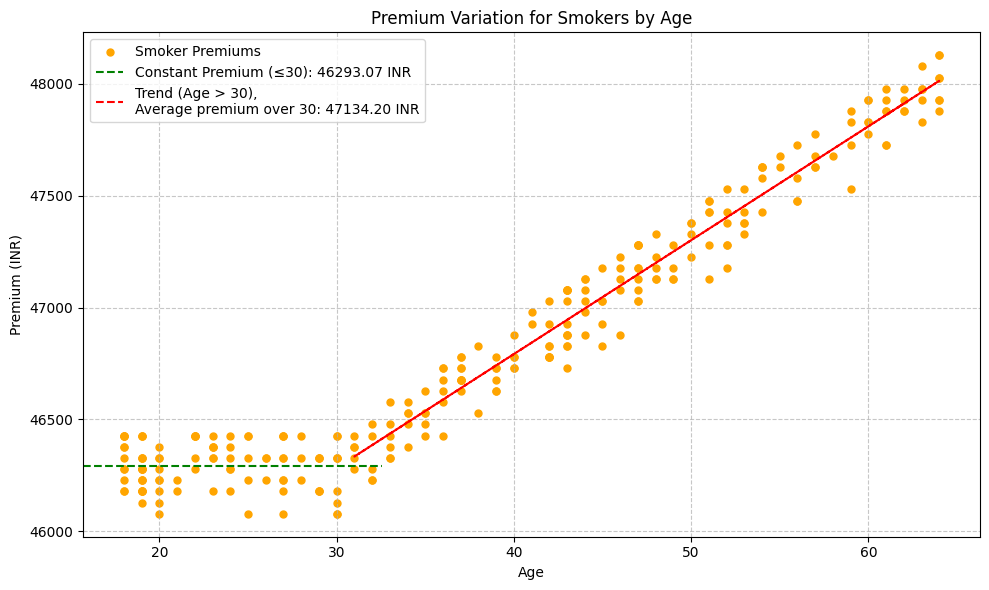

In [ ]:
smoker_data=df.query("smoker_boolean==True")[["age","premium"]]
plt.figure(figsize=(10, 6))


plt.scatter(smoker_data["age"], smoker_data["premium"], color="orange", s=25, label="Smoker Premiums")

under_30_data = smoker_data[smoker_data["age"] <= 30]
if not under_30_data.empty:
    expected_premium = under_30_data["premium"].mean()
    plt.axhline(y=expected_premium, xmin=0, xmax=2/6, color="green", linestyle="--", label=f"Constant Premium (≤30): {expected_premium:.2f} INR")

over_30_data = smoker_data[smoker_data["age"] > 30]
if not over_30_data.empty:
    z = np.polyfit(over_30_data["age"], over_30_data["premium"], 1)
    p = np.poly1d(z)
    plt.plot(over_30_data["age"], p(over_30_data["age"]), "r--", label=f"Trend (Age > 30),\nAverage premium over 30: {over_30_data['premium'].mean():.2f} INR")

plt.title("Premium Variation for Smokers by Age", fontsize=12)
plt.xlabel("Age", fontsize=10)
plt.ylabel("Premium (INR)", fontsize=10)
plt.grid(True, linestyle="--", alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

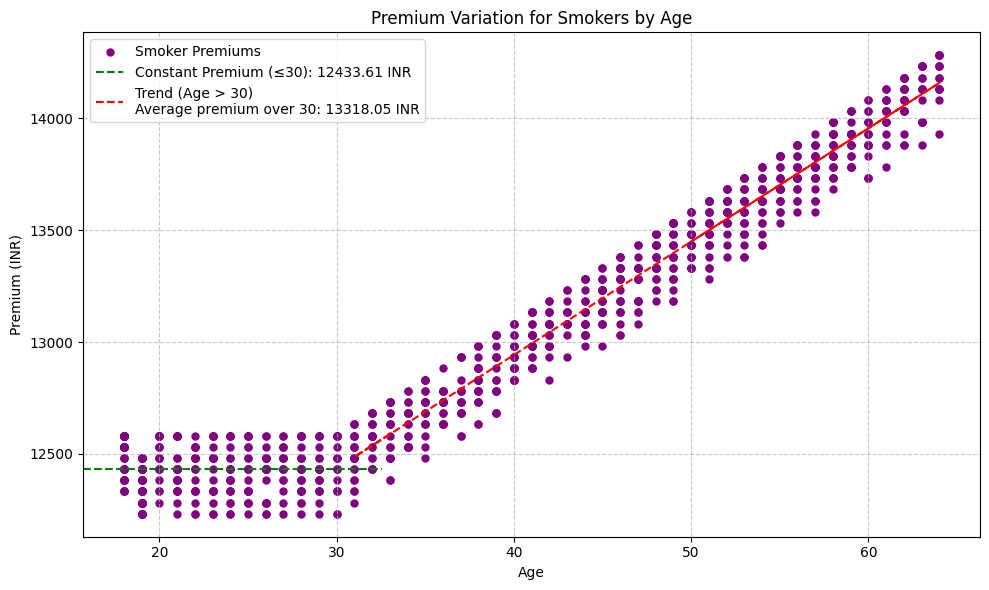

In [ ]:
smoker_data=df.query("smoker_boolean==False")[["age","premium"]]
plt.figure(figsize=(10, 6))


plt.scatter(smoker_data["age"], smoker_data["premium"], color="purple", s=25, label="Smoker Premiums")

under_30_data = smoker_data[smoker_data["age"] <= 30]
if not under_30_data.empty:
    expected_premium = under_30_data["premium"].mean()
    plt.axhline(y=expected_premium, xmin=0, xmax=2/6, color="green", linestyle="--", label=f"Constant Premium (≤30): {expected_premium:.2f} INR")

over_30_data = smoker_data[smoker_data["age"] > 30]
if not over_30_data.empty:
    z = np.polyfit(over_30_data["age"], over_30_data["premium"], 1)
    p = np.poly1d(z)
    plt.plot(over_30_data["age"], p(over_30_data["age"]), "r--", label=f"Trend (Age > 30)\nAverage premium over 30: {over_30_data['premium'].mean():.2f} INR")

plt.title("Premium Variation for Smokers by Age", fontsize=12)
plt.xlabel("Age", fontsize=10)
plt.ylabel("Premium (INR)", fontsize=10)
plt.grid(True, linestyle="--", alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

Scipy version: 1.15.2
Scipy location: c:\Python312\Lib\site-packages\scipy\__init__.py


In [56]:
df["charges"].mode()[0]


np.float64(1639.5631)

In [57]:
df["charges"].min()

np.float64(1121.8739)

In [ ]:
df.query("smoker_boolean==False")["premium"]

Statistical Metrics for Medical Charges (INR):
Mean: 13270.42
Median: 9382.03
Std Dev: 12110.01
Mode: 1639.56
Q1 (25th): 4740.29
Q3 (75th): 16639.91
IQR: 11899.63
Skewness: 1.51
Kurtosis: 1.60
Min: 1121.87
Max: 63770.43


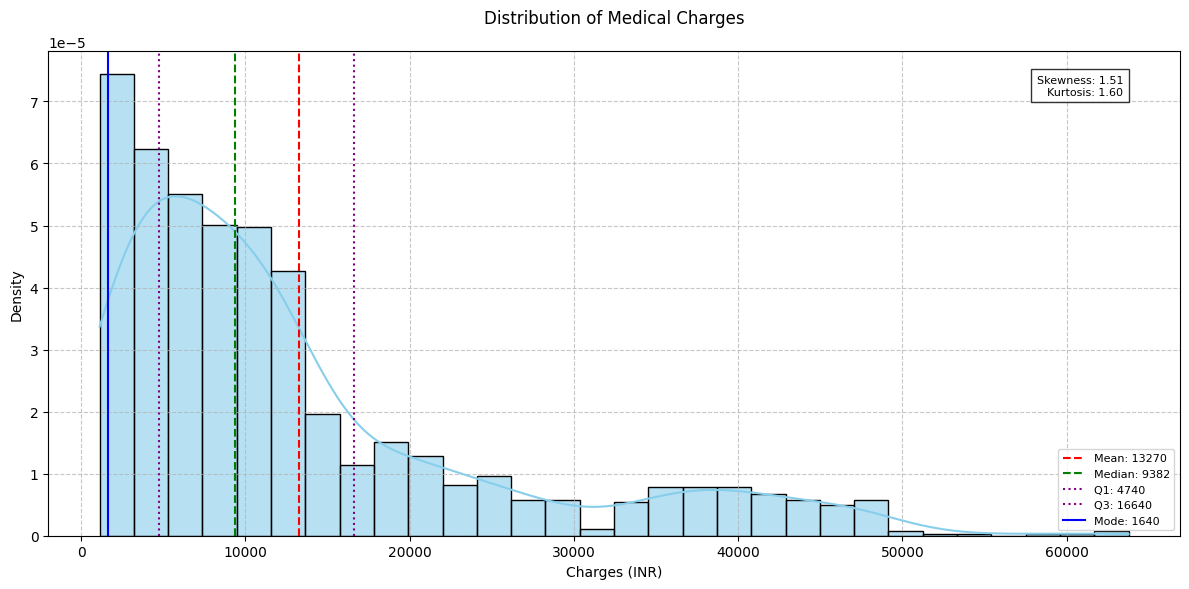

In [ ]:
charges_stats = {
    "Mean": df["charges"].mean(),
    "Median": df["charges"].median(),
    "Std Dev": df["charges"].std(),
    "Mode": df["charges"].mode()[0],
    "Q1 (25th)": df["charges"].quantile(0.25),
    "Q3 (75th)": df["charges"].quantile(0.75),
    "IQR": df["charges"].quantile(0.75) - df["charges"].quantile(0.25),
    "Skewness": skew(df["charges"].dropna()),
    "Kurtosis": kurtosis(df["charges"].dropna()),
    "Min": df["charges"].min(),
    "Max": df["charges"].max()
}


print("Statistical Metrics for Medical Charges (INR):")
for key, value in charges_stats.items():
    print(f"{key}: {value:.2f}")


plt.figure(figsize=(12, 6))
sns.histplot(data=df, x="charges", bins=30, kde=True, color="skyblue", stat="density", alpha=0.6)


plt.axvline(charges_stats["Mean"], color="red", linestyle="--", label=f"Mean: {charges_stats['Mean']:.0f}")
plt.axvline(charges_stats["Median"], color="green", linestyle="--", label=f"Median: {charges_stats['Median']:.0f}")
plt.axvline(charges_stats["Q1 (25th)"], color="purple", linestyle=":", label=f"Q1: {charges_stats['Q1 (25th)']:.0f}")
plt.axvline(charges_stats["Q3 (75th)"], color="purple", linestyle=":", label=f"Q3: {charges_stats['Q3 (75th)']:.0f}")
plt.axvline(charges_stats["Mode"], color="blue", linestyle="-", label=f"Mode: {charges_stats['Mode']:.0f}")

plt.title("Distribution of Medical Charges", fontsize=12, pad=20)
plt.xlabel("Charges (INR)", fontsize=10)
plt.ylabel("Density", fontsize=10)
plt.grid(True, linestyle="--", alpha=0.7)


plt.legend(fontsize=8)


plt.text(0.95, 0.95, f"Skewness: {charges_stats['Skewness']:.2f}\nKurtosis: {charges_stats['Kurtosis']:.2f}",
         transform=plt.gca().transAxes, fontsize=8, verticalalignment='top', horizontalalignment='right',
         bbox=dict(facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

## Observations and Inferences on Medical Charges Distribution

### Key Insights from the Distribution
- **Right-Skewed Distribution**: The KDE curve and histogram show a right-skewed distribution, with a peak around 5,000–10,000 INR and a long tail extending to 63,770 INR. This indicates that while most policyholders have relatively low medical charges, a small subset incurs significantly higher costs - (the smoker group with their substantial expected claims).
- **Mean vs. Median**: The mean (13,270 INR) is higher than the median (9,382 INR), confirming the influence of high-charge outliers on the average, which supports the need for risk segmentation to avoid overcharging low-risk policyholders.
- **Quartile Spread**: The interquartile range (IQR) of 11,900 INR (Q1: 4,740 INR, Q3: 16,640 INR) shows that the middle 50% of charges are concentrated, but the long tail pushes the distribution beyond 16,640 INR, highlighting variability.
- **Skewness and Kurtosis**: A skewness of 1.51 and kurtosis of 1.60 indicate a non-normal distribution with a pronounced right tail and heavier tails than a normal distribution, suggesting as a result of factors like somking which results in the tail of the curve to be at the extreme end (small group) and the non smokers comprising the major chunk of the data resulting in a peak towards the left end of the curve (right skewness).

### Implications for Pricing Strategy
- **Risk Segmentation**: The right-skewed nature and high-cost tail validate the  approach of segmenting premiums by smoker status, BMI, and region. For instance, smokers and obese individuals (likely in the tail) should face higher premiums.The difference between mean and median indicates that a flat premium (based on mean) would overcharge the majority. Segmenting by risk factors ensures fairness.
- **Risk Margin**: The maximum charge (63,770 INR) suggests a need to cap or adjust premiums for extreme cases, possibly through reinsurance or additional risk margins, as implemented in the `premium_calculator.py`.


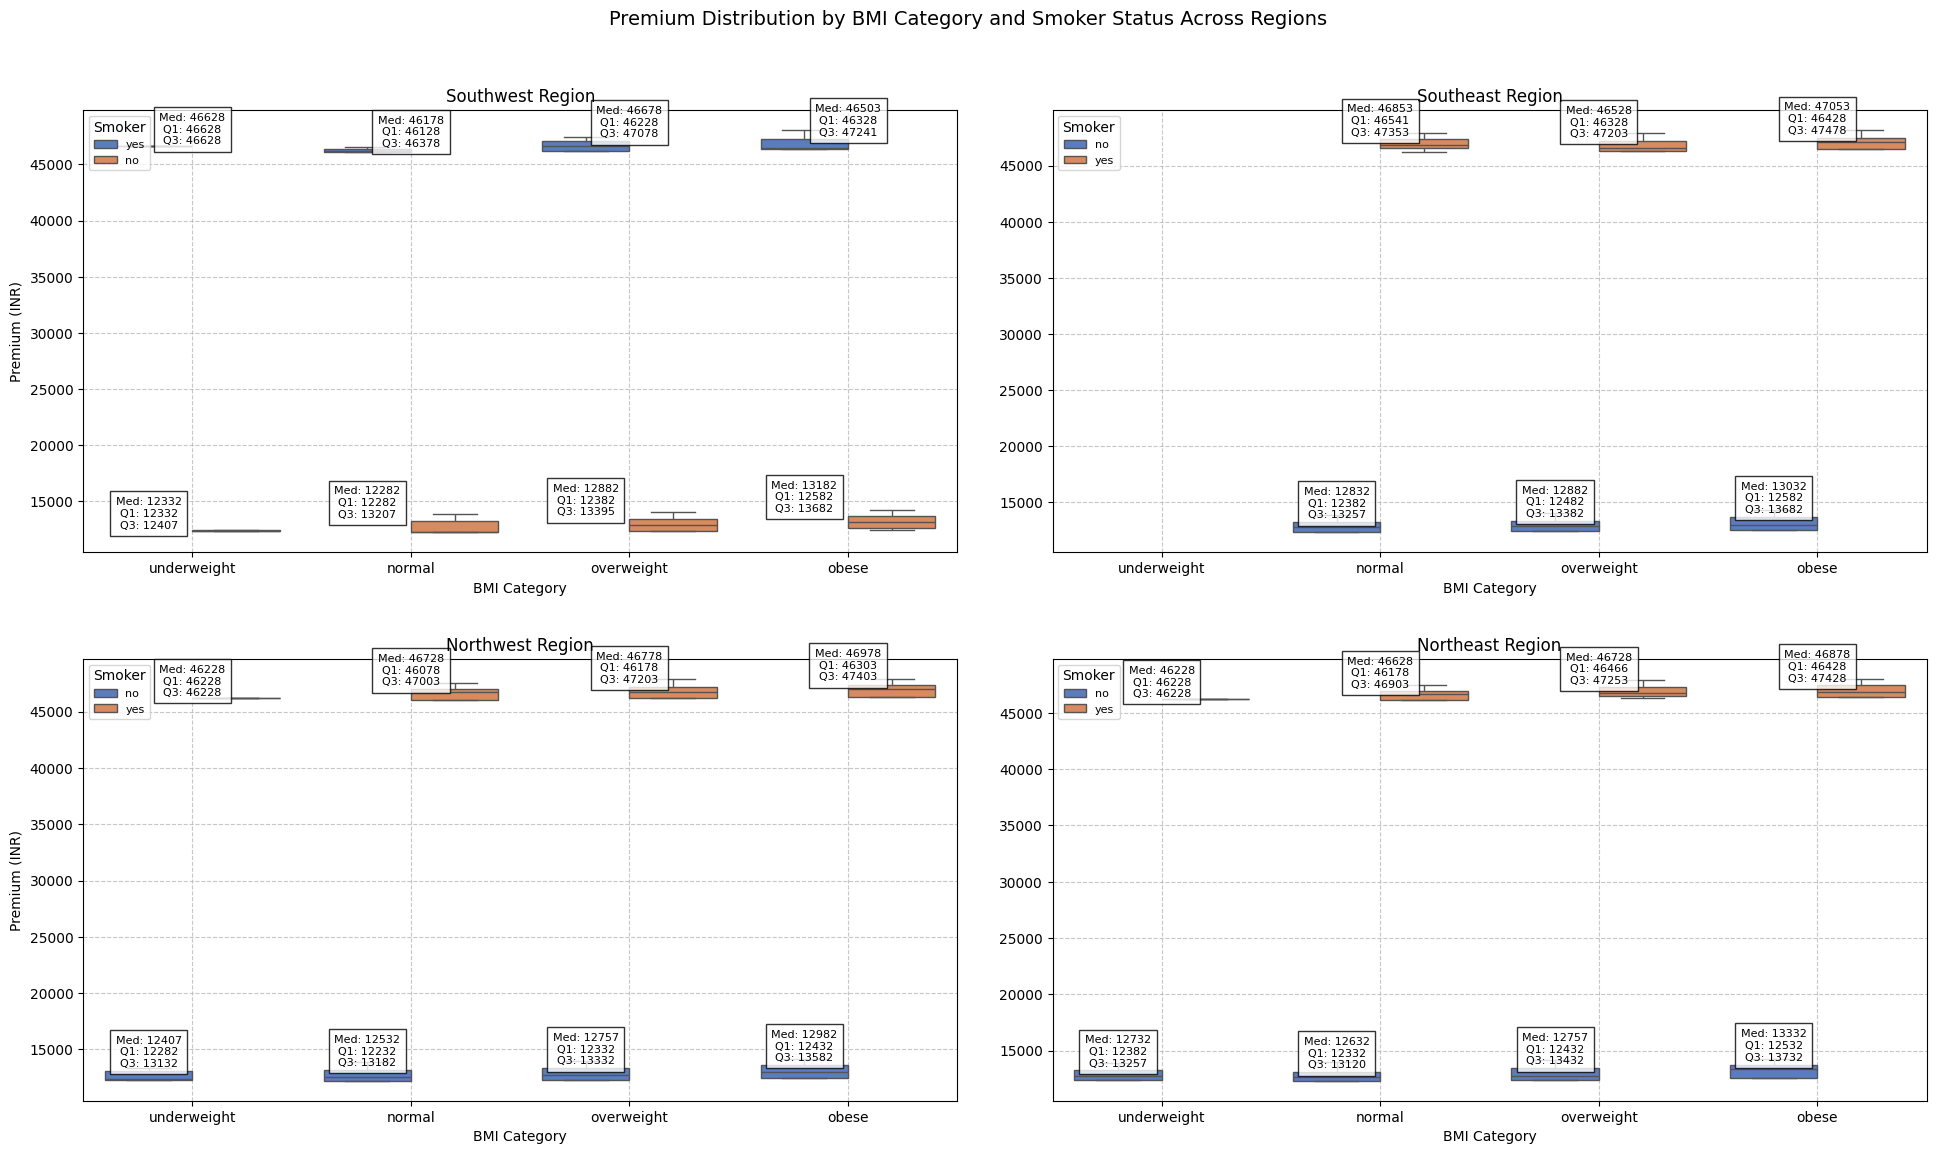

In [ ]:

regions = ['southwest', 'southeast', 'northwest', 'northeast']
plt.figure(figsize=(20, 12))

for i, region in enumerate(regions):
    plt.subplot(2, 2, i+1)
    region_data = df[df['region'] == region]
    ax = sns.boxplot(x="bmi_category", y="premium", hue="smoker", palette="muted", data=region_data)
    
    
    for j, category in enumerate(['underweight', 'normal', 'overweight', 'obese']):
        for k, smoker in enumerate([False, True]):
            data = region_data[(region_data['bmi_category'] == category) & (region_data['smoker_boolean'] == smoker)]['premium'].dropna()
            if not data.empty:
                q1 = data.quantile(0.25)
                median = data.median()
                q3 = data.quantile(0.75)
                y_pos = q3 + (q3 - q1) * 0.2  
                ax.text(j - 0.2 + k * 0.2, y_pos, f'Med: {median:.0f}\nQ1: {q1:.0f}\nQ3: {q3:.0f}',
                        ha='center', va='bottom', fontsize=8, color='black',
                        bbox=dict(facecolor='white', alpha=0.8))

    plt.title(f"{region.capitalize()} Region", fontsize=12)
    plt.xlabel("BMI Category", fontsize=10)
    plt.ylabel("Premium (INR)" if i % 2 == 0 else "", fontsize=10)
    plt.grid(True, linestyle="--", alpha=0.7)
    plt.legend(title="Smoker", loc='upper left' if i == 0 else 'best', fontsize=8)

plt.suptitle("Premium Distribution by BMI Category and Smoker Status Across Regions", fontsize=14)
plt.tight_layout(pad=3.0)
plt.show()